In [1]:
import numpy as np
import pandas as pd

import scarf

# Keep routine execution diagnostics out of the marker figures.
scarf.configure_output(level="WARNING", progress=False)

# Download the prepared example, including its saved analysis.
dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq", destination="scarf_datasets", zarr=True
)

Downloading bucket files: 56215324 / 56215324 complete

Downloading bytes: 56215324 / 56215324 complete

In [2]:
# Open the datastore for the following analysis.
ds = scarf.DataStore(f"{dataset}/data.zarr")
# Open the saved analysis and retain its exact results.
run = ds.pipeline.open(label="docs_default")
# Keep the exact clustering result.
clusters = run["clusters"]
# Rank markers for the saved clusters over every gene that the run analyzed.
markers = ds.run_marker_search(clusters, features=run["feature_universe"])
# Read the cluster labels in the run's cell order.
cluster_values = run.cells.fetch("clusters").astype(str)
# Inspect the opened assays and their dimensions.
ds

DataStore has 3948 (5025) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_G2M_score', 'RNA_S_score', 
            'RNA_UMAP1', 'RNA_UMAP2', 'RNA_cell_cycle_phase', 'RNA_clusters', 'RNA_doublet_score', 
            'RNA_leiden_cluster', 'RNA_nCounts', 'RNA_nFeatures', 'RNA_paris_cluster', 'RNA_percentMito', 
            'RNA_percentRibo'
   RNA assay has 33538 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'feature_type', 
            'genome', 'nCells'

In [3]:
# Load the marker evidence for cluster 1.
group_markers = ds.get_markers(marker=markers, group_id="1")
# Inspect the ten leading markers and their supporting statistics.
marker_columns = [
    "feature_name",
    "score",
    "frac_exp",
    "fold_change",
    "auc",
    "p_value_adjusted",
]
# Preview the ten leading rows using those evidence columns.
group_markers[marker_columns].head(10)

,feature_name,score,frac_exp,fold_change,auc,p_value_adjusted
0,S100A12,0.95617,0.93994,815.52981,0.96916,0.0
1,VCAN,0.92713,0.96648,360.28912,0.98244,0.0
2,CD14,0.92068,0.95251,419.17110,0.97550,0.0
3,ALDH1A1,0.90752,0.51816,646.32933,0.75854,0.0
4,CLEC4E,0.90587,0.58659,834.76424,0.79282,0.0
5,LGALS2,0.90344,0.55587,243.49814,0.77642,0.0
6,CD163,0.89379,0.50419,433.35070,0.75137,0.0
7,QPCT,0.88405,0.46788,370.17063,0.73317,0.0
8,CYP27A1,0.88355,0.46648,363.40352,0.73234,0.0
9,STAB1,0.87829,0.62430,93.18504,0.80792,0.0


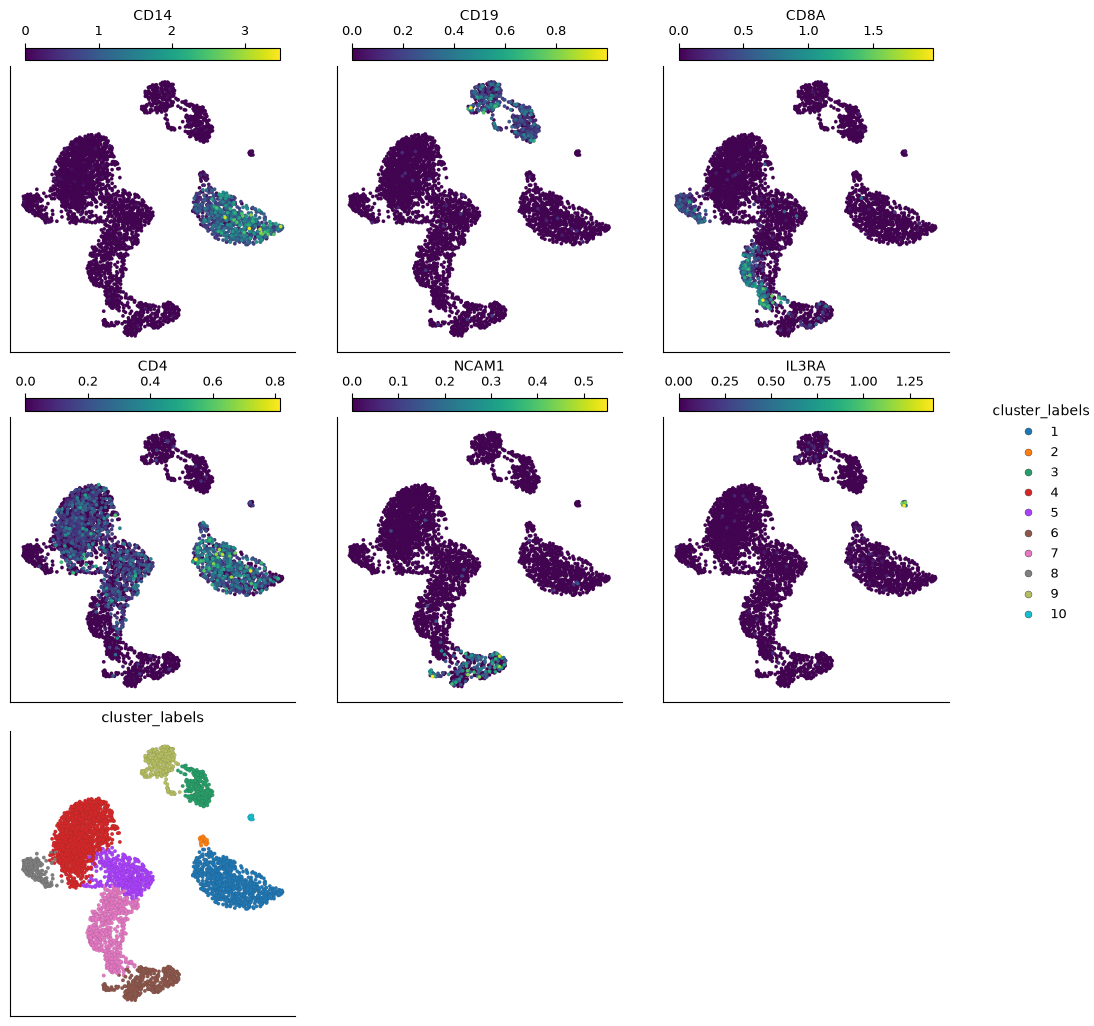

In [4]:
# Choose a small marker panel for the comparison.
panel_genes = ["CD14", "CD19", "CD8A", "CD4", "NCAM1", "IL3RA"]
# Compare the initial marker panel with the saved clusters.
ds.plots.embedding(
    layout=run["umap"], color_by=[*panel_genes, clusters], n_columns=3, sort_values=True
)

In [5]:
# Include weak and negative marker evidence for the remaining checks.
all_markers = ds.get_markers(marker=markers, min_score=-1, min_frac_exp=-1)
# Keep the marker statistics for the chosen genes.
panel_stats = all_markers[all_markers["feature_name"].isin(panel_genes)]
# Find the highest-scoring cluster for each marker.
panel_best = (
    panel_stats.sort_values("score", ascending=False)
    .groupby("feature_name", sort=False)
    .head(1)
    .set_index("feature_name")
    .reindex(panel_genes)
)
# Inspect the strongest cluster association for each panel gene.
panel_best[["group_id", "score", "frac_exp", "auc"]].round(2)

,group_id,score,frac_exp,auc
feature_name,,,,
CD14,1,0.92,0.95,0.98
CD19,9,0.54,0.61,0.78
CD8A,8,0.51,0.87,0.88
CD4,1,0.33,0.75,0.77
NCAM1,6,0.76,0.40,0.70
IL3RA,10,0.81,1.00,1.00


In [6]:
# Record the broad identities suggested by the initial marker panel.
proposed_labels = {
    "1": "CD14 monocytes",
    "2": "monocytes",
    "3": "B cells",
    "4": "T cells",
    "5": "T cells",
    "6": "NK cells",
    "7": "T cells",
    "8": "T cells",
    "9": "B cells",
    "10": "pDC-like cells",
}
# Display the initial cluster-to-cell-type proposals.
pd.Series(proposed_labels, name="proposed_cell_type")

1     CD14 monocytes
2          monocytes
3            B cells
4            T cells
5            T cells
6           NK cells
7            T cells
8            T cells
9            B cells
10    pDC-like cells
Name: proposed_cell_type, dtype: str

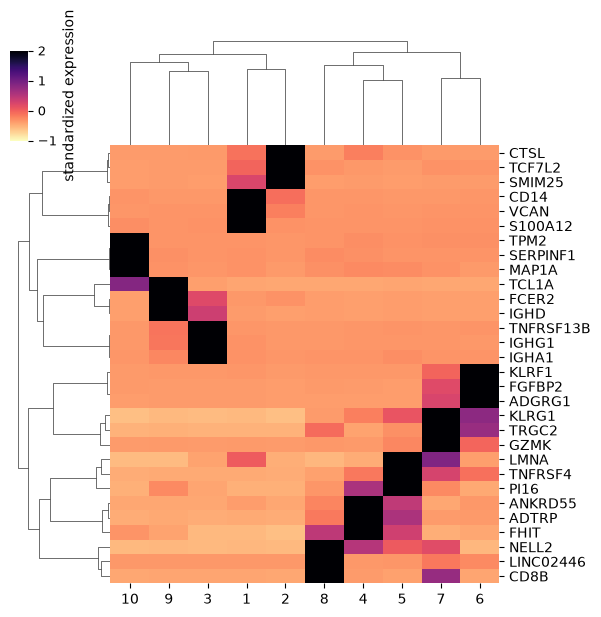

In [7]:
# Compare the leading markers across the saved clusters.
ds.plots.marker_heatmap(marker=markers, topn=3, figsize=(6, 6))

In [8]:
# Choose markers for T-cell identity and state.
t_cell_genes = ["CD3D", "CD8A", "CD8B", "CCR7", "IL7R", "CD27", "GZMK"]
# Select the marker rows for the two T-cell groups.
t_cell_evidence = all_markers[
    all_markers["group_id"].isin(["7", "8"])
    & all_markers["feature_name"].isin(t_cell_genes)
]
# Inspect T-cell marker detection and specificity in clusters 7 and 8.
t_cell_evidence[["group_id", "feature_name", "frac_exp", "score"]].round(2)

,group_id,feature_name,frac_exp,score
201228,7,GZMK,0.72,0.83
201235,7,CD8A,0.43,0.39
201313,7,CD3D,0.98,0.26
201315,7,CD8B,0.41,0.26
201326,7,IL7R,0.76,0.25
202501,7,CD27,0.53,0.15
234263,7,CCR7,0.14,0.03
234767,8,CD8B,0.95,0.70
234769,8,CD8A,0.87,0.51
234793,8,CCR7,0.85,0.30


In [9]:
# Choose markers that distinguish the competing cell identities.
comparison_genes = ["CD3D", "CD3E", "CD4", "NKG7", "GNLY", "CD8A", "CD8B"]
# Keep evidence for the two populations under review.
comparison = all_markers[
    all_markers["group_id"].isin(["6", "8"])
    & all_markers["feature_name"].isin(comparison_genes)
]
# Compare marker detection inside and outside the competing populations.
comparison[["group_id", "feature_name", "frac_exp", "frac_exp_rest", "auc"]].round(2)

,group_id,feature_name,frac_exp,frac_exp_rest,auc
167700,6,GNLY,1.00,0.10,1.00
167731,6,NKG7,1.00,0.21,0.99
175505,6,CD3D,0.31,0.65,0.39
176657,6,CD3E,0.43,0.66,0.40
200042,6,CD8A,0.11,0.11,0.50
201125,6,CD4,0.02,0.39,0.31
201165,6,CD8B,0.00,0.12,0.44
234767,8,CD8B,0.95,0.08,0.95
234769,8,CD8A,0.87,0.08,0.88
234845,8,CD3E,0.99,0.63,0.70


In [10]:
# Refine only the identities supported by the additional evidence.
final_labels = proposed_labels | {
    "3": "memory B cells",
    "5": "CD4+ T cells",
    "7": "CD8+ T cells",
    "8": "naive CD8 T cells",
    "9": "naive B cells",
}
# Put the initial and reviewed labels beside each other.
label_review = pd.DataFrame({"initial": proposed_labels, "reviewed": final_labels})
# Display only the labels changed during review.
label_review.loc[label_review["initial"] != label_review["reviewed"]]

,initial,reviewed
3,B cells,memory B cells
5,T cells,CD4+ T cells
7,T cells,CD8+ T cells
8,T cells,naive CD8 T cells
9,B cells,naive B cells


In [11]:
# Locate the run's selected cells on the full metadata axis.
analysis_cells = run.cells.fetch_all("I").astype(bool)
# Reserve a label for every cell, including cells outside the run.
initial_cell_type = np.full(ds.cells.N, "Not analyzed", dtype=object)
# Reserve the same full cell axis for the reviewed labels.
reviewed_cell_type = np.full(ds.cells.N, "Not analyzed", dtype=object)
# Place the initial labels into the selected physical rows.
initial_cell_type[analysis_cells] = [proposed_labels[value] for value in cluster_values]
# Place the reviewed labels into those same rows.
reviewed_cell_type[analysis_cells] = [final_labels[value] for value in cluster_values]
# Save the values in cell metadata using the stated selection.
ds.cells.insert("proposed_cell_type", initial_cell_type, overwrite=True)
# Save the values in cell metadata using the stated selection.
ds.cells.insert("reviewed_cell_type", reviewed_cell_type, overwrite=True)
# Count cells assigned to each reviewed identity.
pd.Series(reviewed_cell_type[analysis_cells]).value_counts().rename("cells")

T cells              1241
CD14 monocytes        716
CD8+ T cells          552
CD4+ T cells          434
NK cells              319
naive B cells         256
memory B cells        239
naive CD8 T cells     151
monocytes              25
pDC-like cells         15
Name: cells, dtype: int64

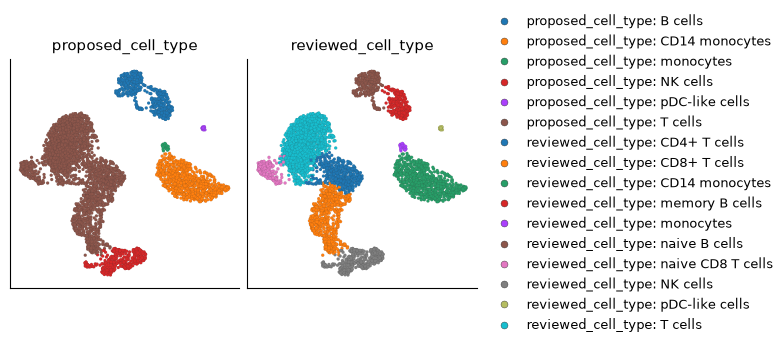

In [12]:
# Compare the original and reviewed annotations on the same UMAP.
ds.plots.embedding(
    layout=run["umap"], color_by=["proposed_cell_type", "reviewed_cell_type"]
)